In [1]:
import numpy as np
from scipy.optimize import minimize
import pandas as pd
from scipy.special import expit
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.spatial import distance
import statsmodels.api as sm
import warnings
import numpy as np
from scipy.optimize import differential_evolution
from scipy.stats import rankdata
from sklearn.cross_decomposition import CCA
import math
import copy
from math import log
from collections import Counter
import pickle
from sklearn.linear_model import Lasso
warnings.filterwarnings("ignore")

In [2]:
# Read beta back from the file
beta_star = np.load('beta_star.npy')
print("beta_star:", beta_star)
n_features = len(beta_star)

np.sum(beta_star[beta_star > 0])

beta_star: [ 0.          0.          0.          0.          0.          0.
  0.          0.         -9.35929044 -8.23056672  0.          0.
  0.          0.          0.          0.          0.         -1.93149689
  0.          0.          0.          0.          0.          0.
  0.          0.         -4.01959343  0.          4.46057556  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          3.62310545  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          2.16801674  0.          0.
  0.         -1.45199639  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  5.18683686  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.  

15.438534611441117

In [3]:
from sklearn.linear_model import Lasso

def lasso_stochastic_bandit(phi, T, C_max_wave, L, error_std, Y_t, X_t, beta_star):
    """
    Implements the preconditioning LASSO bandit algorithm.

    Args:
        phi (float): Regularization parameter for optimization.
        T (int): Total time steps.
        C_max_wave (float): F_t matrix eigenvalue constraint.
        L (float): Upper limit for X values.
        error_std (float): Standard deviation for error term.
        Y_t (array): Initial response vector.
        X_t (array): Initial feature matrix.
        beta_star (array): True coefficient vector for simulation.

    Returns:
        Y_t, X_t: Updated response vector and feature matrix.
    """
    n_features = X_t.shape[1]  # Number of features

    Y_t_exp = Y_t

    l_2_error_parameter = np.array([])

    for tau in range(len(Y_t), T):
        # Compute lambda for LASSO
        lamada = 2 * error_std * C_max_wave * L * np.sqrt(2 * (2 * np.log(tau) + np.log(n_features)) / tau)

        # Perform LASSO regression with lambda using Y_t_tran and X_t_tran
        lasso = Lasso(alpha=lamada, fit_intercept=False)
        lasso.fit(X_t, Y_t)  # Fit the model to get beta estimates
        beta_esti = lasso.coef_  # Estimated beta values
        #print(f"parameter square error:{np.sqrt(sum((beta_esti - beta_star)**2))}")
        s = np.count_nonzero(beta_star)  # Number of non-zero coefficients

        # Perform optimization to find X_max
        # Check if expected Y_t has not changed for 20 iterations
        if len(Y_t_exp) >= 20 and np.all(Y_t_exp[-20:] == Y_t_exp[-1]):
            # Keep X_max unchanged
            X_max = X_t[-1]
        else:
            # Perform optimization to find X_max
            X_max = optimization(beta_esti, s, X_t, L, lamada, phi, tau)

        # Generate Y_max based on true beta_star
        Y_max = beta_star @ X_max + np.random.normal(0, error_std, 1)

        # Generate Y_max based on true beta_star
        Y_max_exp = beta_star @ X_max
    
        #print(f"time {tau}: mean reward {beta_star @ X_max}")
        #print(f"time {tau}: action {X_max}")

        l_2_error_parameter = np.append(l_2_error_parameter, np.sqrt(sum((beta_esti - beta_star)**2)))

        # Append X_max and Y_max to X_t and Y_t
        Y_t = np.append(Y_t, Y_max)
        X_t = np.vstack([X_t, X_max])

        Y_t_exp = np.append(Y_t_exp, Y_max_exp)

    return Y_t, X_t, Y_t_exp, l_2_error_parameter


In [4]:
def optimization(beta_esti, s, X_t, L, lamada, phi, tau):
    """
    Perform optimization using a hill-climbing algorithm under given constraints.

    Args:
        beta_esti (numpy array): Estimated coefficients (beta).
        s_esti (float): Estimated parameter for scaling.
        X_t (numpy array): Existing feature matrix.
        lamada (float): Regularization parameter.
        phi (float): Parameter for constraint.
        C_max_wave (float): Constraint for F_t matrix eigenvalue.
        t (int): Time step or scaling factor.
        max_iterations (int): Maximum number of iterations for the algorithm.

    Returns:
        numpy array: Optimized X_max vector.
    """
    # Define the objective function
    # Define the objective function
    def objective(X_max):
        d = len(beta_star)
        X_max = np.array(X_max)
        sqrt_term = np.sqrt(X_max @ np.linalg.pinv((1 / tau) * (X_t.T @ X_t)) @ X_max.reshape(-1, 1))
        constant = 50 * (np.log(1000) + s * np.sqrt(np.log(d)) + s) * np.sqrt(np.log(tau)) / tau
        return -(beta_esti @ X_max + constant * sqrt_term)  # Negate for maximization
    
    # Initialize X_max with all zeros
    num_vars = len(beta_esti)
    X_max = np.random.choice([0, L], size=num_vars)

    epochs = 1
    for epoch in range(epochs):
        current_value = objective(X_max)

        # Greedy optimization within this epoch
        for i in range(num_vars):
            # Flip the value of X_max[i] (0 -> L, L -> 0)
            original_value = X_max[i]
            X_max[i] = 0 if original_value == L else L
            new_value = objective(X_max)

            # If the objective improves, keep the change; otherwise, revert
            if new_value < current_value:
                current_value = new_value
            else:
                X_max[i] = original_value

    return X_max


# Lasso Stochastic Bandit

In [5]:
def while_lasso_stochastic_bandit(beta_star):
    error_std = 1
    phi = 50
    C_max_wave = 1
    t = 2
    T = 1000 + t
    L = 1
    # Generate X where the first column is 1, and the remaining columns are random values
    X_t = np.ones((t, n_features))  # Start with an array of ones
    X_t[:, 1:] = np.random.uniform(0, L, (t, n_features - 1))  # Fill the remaining columns with random values
    
    # Generate random error term
    error_t = np.random.normal(0, error_std, t)
    
    # Compute Y = X @ beta_star + error_t
    Y_t = X_t @ beta_star + error_t
    
    Y_T, X_T, Y_t_exp, l_2_error_parameter = lasso_stochastic_bandit(phi, T, C_max_wave, L, error_std, Y_t, X_t, beta_star)

    return Y_t_exp, l_2_error_parameter

In [6]:
cumulative_regre_times = []
l_2_error_parameter_times = []

# Run the experiment 10 times
for times in range(10):
    print(f"experiment time: {times + 1}")
    # Ensure beta_star and `t` are properly initialized
    Y_t_exp, l_2_error_parameter = while_lasso_stochastic_bandit(beta_star)  # Replace with the actual function
    Y_t_to_T = Y_t_exp
    
    # Calculate instantaneous regret
    instantaneous_regret = np.sum(beta_star[beta_star > 0]) - Y_t_to_T
    instantaneous_regret = np.where(instantaneous_regret < 0.002, 0, instantaneous_regret)  # Threshold adjustment

    # Calculate cumulative regret
    cumulative_regret = np.cumsum(instantaneous_regret)

    # Append results to the list
    cumulative_regre_times.append(cumulative_regret)
    l_2_error_parameter_times.append(l_2_error_parameter)

# The results `cumulative_regre_times` and `l_2_error_parameter_times` now store the outcomes of all experiments.

experiment time: 1
experiment time: 2
experiment time: 3
experiment time: 4
experiment time: 5
experiment time: 6
experiment time: 7
experiment time: 8
experiment time: 9
experiment time: 10


In [7]:
# Convert lists to NumPy arrays for easier computation
cumulative_regret_times = np.array(cumulative_regre_times)
l_2_error_parameter_times = np.array(l_2_error_parameter_times)

# Calculate the mean and standard deviation along the "times" axis
cumulative_regret_mean = np.mean(cumulative_regret_times, axis=0)
cumulative_regret_std = np.std(cumulative_regret_times, axis=0)

l_2_error_parameter_mean = np.mean(l_2_error_parameter_times, axis=0)
l_2_error_parameter_std = np.std(l_2_error_parameter_times, axis=0)

# Print or use the results as needed
print("Cumulative Regret Mean:", cumulative_regret_mean)
print("Cumulative Regret Std:", cumulative_regret_std)
print("L2 Error Parameter Mean:", l_2_error_parameter_mean)
print("L2 Error Parameter Std:", l_2_error_parameter_std)

Cumulative Regret Mean: [  27.87790789   48.76108055   77.54194633 ... 5752.64067288 5753.94612015
 5755.01046767]
Cumulative Regret Std: [  4.59367845   5.71953804   6.69788616 ... 187.12935702 187.784071
 188.01820305]
L2 Error Parameter Mean: [17.26122316 17.18573684 16.79444517 15.99127001 16.40147716 15.85656084
 15.84941449 15.52588026 15.45737911 15.30708211 15.04875996 15.10760613
 15.46735134 15.3234686  14.63750886 14.27356195 13.64273849 13.64143365
 13.57328907 13.73168396 13.63313568 13.46593918 13.29527784 13.01229877
 12.92282354 12.84183072 12.66704509 12.84811413 12.8039588  12.62817098
 12.51146052 12.49239037 12.43516947 12.34824534 12.34995708 12.27275839
 12.16630512 12.17827667 12.03785718 11.89374738 11.81266114 11.81714401
 11.79694092 11.78541756 11.69419511 11.58958769 11.51202189 11.38240564
 11.35325808 11.31397587 11.24248093 11.22159651 11.16312751 11.13091168
 11.0899556  11.01207064 11.04383948 11.0705606  11.08931532 11.06824769
 11.05714938 11.03437923

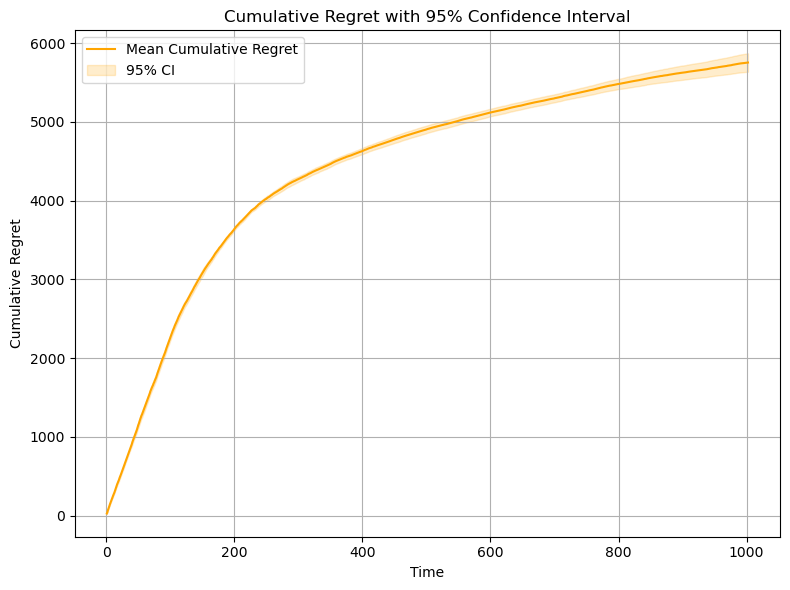

In [8]:
# Calculate the 95% confidence interval for the cumulative regret
lower_bound = cumulative_regret_mean - 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))
upper_bound = cumulative_regret_mean + 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))

# Plot the mean cumulative regret with confidence intervals
plt.figure(figsize=(8, 6))
time_steps = range(1, len(cumulative_regret_mean) + 1)

# Plot the mean line
plt.plot(time_steps, cumulative_regret_mean, label='Mean Cumulative Regret', color='orange')

# Fill the 95% confidence interval
plt.fill_between(time_steps, lower_bound, upper_bound, color='orange', alpha=0.2, label='95% CI')

# Add title, labels, and legend
plt.title('Cumulative Regret with 95% Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Cumulative Regret')
plt.grid()
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


In [9]:
np.save('cumulative_regret_lasso-random-projection-bandit-d100-s10_10times.npy', cumulative_regret_times)
np.save('l_2_error_parameter_lasso-random-projection-bandit-d100-s10_10times.npy', l_2_error_parameter_times)